# Chọn lựa chọn A (lựa chọn ẢNH)

In [93]:
import numpy as np
from PIL import Image

M= []
TARGET_SIZE = (512, 512)
image_files = ["1.jpg", "2.jpg", "3.jpg", "4.jpg", "5.jpg", "6.jpg", "7.jpg", "8.jpg","9.jpg"]
for file_name in image_files:
    temp= np.array(Image.open(file_name).resize(TARGET_SIZE).convert("L"),dtype=float)
    #Do là mấy tấm hình ko có cùng kích cỡ (H,W) nên đưa về cùng size để lát nữa xử lý
    print(temp.shape) #Trả về kích thước của ảnh (512, 512)
    M.append(temp)

(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)
(512, 512)


# Bài 1

## Biến dữ liệu thành ma trận

In [94]:
temp_X = []
X = []
for i in range(9):
    temp = M[i].reshape(1,-1) #Ép thành ma trận 1 x (512 x 512)
    temp_X.append(temp)
X = np.vstack(temp_X)
print(X.shape)

(9, 262144)


In ra kích thước ma trận 9 hàng, 512x512 cột. Với mỗi hàng thì trọng số tại các cột biểu diễn cho độ sáng tối (tại vì ảnh đã biến thành ảnh xám nên ko có màu sắc)

## Phép toán cơ bản

In [95]:
X_mean=[]
for i in range(9):
    temp = np.mean(X[i], axis=0) #Trung bình cộng theo chiều dọc
    X_mean.append(temp)
    print(temp)

173.17620849609375
198.75399017333984
206.22621154785156
216.3220329284668
195.81447219848633
188.47772216796875
183.51594924926758
197.72733688354492
181.0876579284668


## Cosine similarity

In [96]:
def cosine_similarity(X, Y=None):
        if Y is None:
            Y = X
        Xn = X/ np.linalg.norm(X, axis=1, keepdims=True) #Chuẩn hoá
        Yn = Y/ np.linalg.norm(Y, axis=1, keepdims=True) #Chuẩn hoá
        return Xn @ Yn.T
print(cosine_similarity(np.atleast_2d(X[0]),np.atleast_2d(X[1])))

[[0.94377246]]


## Truy Vấn

In [97]:
def search(query, top_k=3):
    scores = []

    query = np.atleast_2d(query)

    for i in range(len(X)):
        xi = np.atleast_2d(X[i])
        if np.array_equal(xi, query):
            continue
        else:
            sim = cosine_similarity(query, xi)[0][0]
            scores.append((i, sim))

    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:top_k]

In [98]:
matrix_similarity = search(X[2], 3)
print(matrix_similarity)

[(1, np.float64(0.962974568345295)), (6, np.float64(0.9523756001012821)), (3, np.float64(0.9520153846225696))]


## Cặp giống / Khác nhau

In [99]:
def compare(X):
    best = (-1, -1)
    worst = (-1, -1)

    best_val = -1
    worst_val = 1

    for i in range(9):
        for j in range(i+1, 9):
            sim = cosine_similarity(
                np.atleast_2d(X[i]),
                np.atleast_2d(X[j])
            )[0][0]

            if sim > best_val:
                best_val = sim
                best = (i, j)

            if sim < worst_val:
                worst_val = sim
                worst = (i, j)

    return best, best_val, worst, worst_val

In [100]:
best, best_val, worst, worst_val = compare(X)

print("Giống nhất:", best, best_val)
print("Khác nhất:", worst, worst_val)

Giống nhất: (1, 2) 0.962974568345295
Khác nhất: (0, 4) 0.8996776982352863


# Bài 2

# Biến đổi tuyến tính

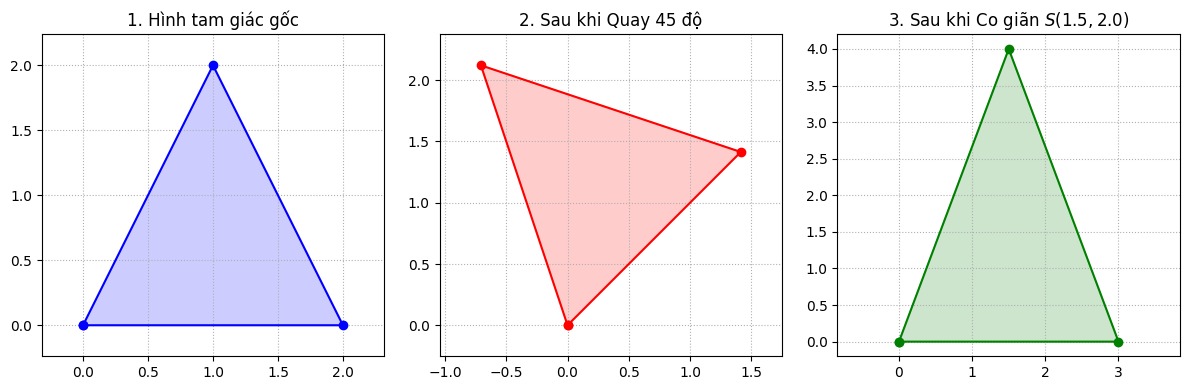

In [102]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [0, 2, 1, 0],  # Hàng x
    [0, 0, 2, 0]   # Hàng y
])

def get_R(theta_degrees):
    """Hàm trả về ma trận quay R(theta) trong không gian 2D"""
    theta = np.radians(theta_degrees) # Chuyển từ độ sang radian
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([
        [c, -s],
        [s,  c]
    ])
    return R

def get_S(sx, sy):
    """Hàm trả về ma trận co giãn S trong không gian 2D"""
    S = np.array([
        [sx,  0],
        [ 0, sy]
    ])
    return S

R = get_R(45)
S = get_S(1.5, 2.0)

points_rotated = R @ points
points_scaled  = S @ points

plt.figure(figsize=(12, 4))

# --- Đồ thị 1: Hình gốc ---
plt.subplot(1, 3, 1)
plt.plot(points[0, :], points[1, :], '-o', color='blue', label='Hình gốc')
plt.fill(points[0, :], points[1, :], color='blue', alpha=0.2)
plt.title("1. Hình tam giác gốc")
plt.grid(True, linestyle=':')
plt.axis('equal')

# --- Đồ thị 2: Sau khi Quay R ---
plt.subplot(1, 3, 2)
plt.plot(points_rotated[0, :], points_rotated[1, :], '-o', color='red', label='Quay 45°')
plt.fill(points_rotated[0, :], points_rotated[1, :], color='red', alpha=0.2)
plt.title("2. Sau khi Quay 45 độ")
plt.grid(True, linestyle=':')
plt.axis('equal')

# --- Đồ thị 3: Sau khi Co giãn S ---
plt.subplot(1, 3, 3)
plt.plot(points_scaled[0, :], points_scaled[1, :], '-o', color='green', label='Co giãn')
plt.fill(points_scaled[0, :], points_scaled[1, :], color='green', alpha=0.2)
plt.title("3. Sau khi Co giãn $S(1.5, 2.0)$")
plt.grid(True, linestyle=':')
plt.axis('equal')

plt.tight_layout()
plt.show()
